In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load & Prepare Jobs
jobs = pd.read_csv("Purdue_Anvil_GPU_2025_jobspecs.csv")
# jobs = pd.read_csv("NCSA_DELTA_GPU_2025_jobspecs.csv")
# jobs = pd.read_csv("Expanse_GPU_2025_jobspecs.csv")

jobs = jobs[[
    'Local Job Id',
    'Submit Time (Timestamp)',
    'Nodes',
    'Gpu Count',
    'Cores',
    'Requested Wall Time',
    'Wall Time',
    'Wait Time'
]].dropna()
# jobs.to_csv("NCSA_DELTA_GPU_2025_relevant_jobspecs.csv")

# Rename for clarity
jobs.columns = [
    'job_id',
    'submit_time',
    'nodes',
    'gpus',
    'cores',
    'requested_wall_time',
    'actual_wall_time',
    'actual_wait_time'
]

# Convert time
# jobs['submit_time'] = pd.to_datetime(jobs['submit_time'], unit='s', utc=True)
# jobs['submit_time'] = pd.to_timedelta(jobs['submit_time'], unit='s', errors='coerce')
# jobs['actual_wall_time'] = pd.to_timedelta(jobs['actual_wall_time'], unit='s', errors='coerce')


# # UPGRADE RESOURCES
# jobs['actual_wall_time'] = jobs['actual_wall_time'] * 0.8

jobs['submit_time'] = pd.to_timedelta(jobs['submit_time'], unit='s', errors='coerce')
jobs['actual_wall_time'] = pd.to_timedelta(jobs['actual_wall_time'], unit='s', errors='coerce')

# Sort (FCFS)
jobs = jobs.sort_values(by='submit_time').reset_index(drop=True)

# Add scheduling columns
# jobs['start_time'] = None
# jobs['end_time'] = None

jobs['start_time'] = pd.NaT
jobs['end_time'] = pd.NaT


# Available Resources
available = {
    "cores": 2211, # 12211, # 1872, # 1872
    "gpus": 57, # 763, # 187, # 187
    "nodes":14*64 #185*64 #47*64
    }

# Running Jobs Tracker
running_jobs = []

current_time = jobs['submit_time'].min()

# Allocation Function
def allocate(job, current_time, available):
    # 1. Update resources
    available['cores'] -= job['cores']
    available['gpus'] -= job['gpus']
    available['nodes'] -= job['nodes']

    # 2. Assign start time
    start_time = current_time

    # 3. Compute end time
    end_time = start_time + job['actual_wall_time']

    return start_time, end_time

# Free Resources Function
def free_completed_jobs(current_time, running_jobs, available):
    still_running = []

    for r in running_jobs:
        if r['end_time'] <= current_time:
            # Free resources
            available['cores'] += r['cores']
            available['gpus'] += r['gpus']
            available['nodes'] += r['nodes']
        else:
            still_running.append(r)

    return still_running



In [ ]:
# Scheduler Loop
for i, job in jobs.iterrows():

    current_time = max(current_time, job['submit_time'])

    # Free completed jobs first
    running_jobs = free_completed_jobs(current_time, running_jobs, available)

    # Wait until resources available
    while not (
        job['cores'] <= available['cores'] and
        job['gpus'] <= available['gpus'] and
        job['nodes'] <= available['nodes']):

        if i % 10000 == 0:
            print("current job", i)
            print("currently available resorces", available)


        # Move time forward to next job completion
        # if not running_jobs:
        #     current_time = job['submit_time']
        #     break

        next_finish = min(r['end_time'] for r in running_jobs)
        current_time = next_finish

        running_jobs = free_completed_jobs(current_time, running_jobs, available)

    # Allocate
    start_time, end_time = allocate(job, current_time, available)



    # Update dataframe
    jobs.at[i, 'start_time'] = start_time
    jobs.at[i, 'end_time'] = end_time

    # print("current job", jobs.iloc[i])
    
    # Track running job
    running_jobs.append({
        'job_id': job['job_id'],
        'cores': job['cores'],
        'gpus': job['gpus'],
        'nodes': job['nodes'],
        'end_time': end_time
    })

# Final Output
jobs['wait_time'] = jobs['start_time'] - jobs['submit_time']
print("wait_time", jobs['wait_time'])

print(jobs[['submit_time', 'start_time', 'wait_time']].head())
print(jobs['wait_time'].describe())
print(jobs.dtypes)

print("job head",jobs.head())

In [3]:
# Compute WWS
import numpy as np

def compute_wws(wait_times_hours, alpha=0.5, weights=None):
    """
    Compute Weighted Wait-Time Score (WWS)

    Parameters:
    - wait_times_hours: array-like, wait times in hours
    - alpha: weight for zero-wait jobs (default 0.5)
    - weights: list of weights for thresholds [1h, 12h, 1d, 5d]

    Returns:
    - WWS score (float in [0,1])
    """

    wait_times = np.array(wait_times_hours)

    if weights is None:
        weights = [0.2, 0.3, 0.5]

    # Normalize weights (just in case)
    weights = np.array(weights)
    weights = weights / weights.sum()

    # Fractions
    total_jobs = len(wait_times)

    p0 = np.sum(wait_times <= 3600) / total_jobs
    p_1h = np.sum((wait_times > 3600) & (wait_times <= 12 * 3600)) / total_jobs
    p_12h = np.sum((wait_times > 12 * 3600) & (wait_times <= 24 * 3600)) / total_jobs
    p_1d = np.sum(wait_times > 24 * 3600) / total_jobs
    # p_5d = np.sum(wait_times > 120) / total_jobs

    penalties = np.array([p_1h, p_12h, p_1d])
    print("penalties",penalties)

    # Compute WWS
    wws = alpha * p0 + (1 - alpha) * (1 - np.dot(weights, penalties))
    print("alpha * p0", alpha * p0)
    print((1 - alpha) * (1 - np.dot(weights, penalties)))
    print("wws",wws)

    # Clamp to [0,1] (numerical safety)
    return max(0.0, min(1.0, wws))


jobs['wait_time_'] = pd.to_timedelta(jobs['wait_time'], errors='coerce')
# Convert wait time to seconds
jobs['wait_time_sec'] = jobs['wait_time_'].dt.total_seconds()
# jobs['wait_time_min'] = jobs['wait_time_sec'] / 60

wait_times = jobs['wait_time_sec']
score = compute_wws(wait_times)
print(f"WWS Score: {score:.4f}")

In [4]:
# Compute WWS of the actual observ
wait_times_actual = jobs['actual_wait_time']
score_actual = compute_wws(wait_times_actual)
print(f"WWS Score: {score_actual:.4f}")

penalties [0.23380181 0.0520701  0.09403384]
alpha * p0 0.31004712621126
0.4453008445715334
wws 0.7553479707827935
WWS Score: 0.7553


In [13]:
print(max(jobs['actual_wait_time']))

19941565


In [11]:
print(max(jobs['wait_time_sec']))

522712.0


100072
25432
1.0
522712.0


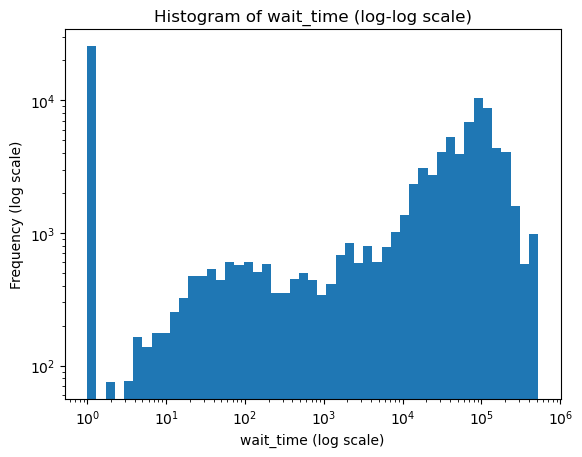

In [15]:
# #_Histogram plot for wait time
# jobs['wait_time_'] = pd.to_timedelta(jobs['wait_time'], errors='coerce')
# # Convert wait time to seconds
# jobs['wait_time_sec'] = jobs['wait_time_'].dt.total_seconds()
# # jobs['wait_time_min'] = jobs['wait_time_sec'] / 60

print(len(jobs['wait_time_sec']))
print((jobs['wait_time_sec'] < 1).sum())

data = jobs['wait_time_sec'] #.dropna()
data = data.replace(0, 1)

print(data.min())
print(data.max())
# Create logarithmically spaced bins
bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 50)

# Plot
plt.figure()
plt.hist(data, bins=bins)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('wait_time (log scale)')
plt.ylabel('Frequency (log scale)')
plt.title('Histogram of wait_time (log-log scale)')

plt.savefig("hist.png")
plt.show()

# # Filter out non-positive values (log scale can't handle zero or negative)
# wait_times = jobs['wait_time_sec']

# # Define log-spaced bins
# log_bins = np.logspace(-1, 7, num=50)  # from 0.1 to 1,000,000 with 50 bins

# plt.figure(figsize=(10, 7))
# sns.histplot(wait_times, bins=log_bins, kde=False, color='blue')

# # Set x-axis to log scale and use matching ticks
# plt.xscale('log')
# plt.xticks([0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000], fontsize=10)

# # Customize labels
# plt.xlabel('Wait Time', fontsize=20)
# plt.ylabel('Frequency', fontsize=20)
# plt.tick_params(axis='both', labelsize=20)  # Set font size for both x and y ticks
# plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# # Show plot
# plt.show()

# # # # Plot histogram
# # plt.figure()
# # plt.hist(jobs['wait_time_sec'], bins=50)
# # # plt.xlabel("Wait Time (minutes)")
# # plt.xlabel("Wait Time (seconds)")
# # plt.ylabel("Number of Jobs")
# # plt.title("Histogram of Job Wait Times (seconds)")
# # plt.savefig('my_plot.png')
# # plt.show()

In [4]:
import pandas as pd
temp = pd.read_csv("Purdue_Anvil_GPU_2025_jobspecs.csv")
temp.columns

/tmp/ipykernel_55051/3390926704.py:2: DtypeWarning: Columns (40) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv("Purdue_Anvil_GPU_2025_jobspecs.csv")


Index(['Unnamed: 0', 'Local Job Id', 'ACCESS Credit Equivalents Charged',
       'Shared', 'Cores', 'Gpu Count', 'Nodes', 'Total Cores Available',
       'Cpu Time', 'Gpu Time', 'Node Time', 'Requested Nodes',
       'Requested Wall Time', 'Queue', 'Wait Time', 'Wall Time',
       'Eligible Time (Timestamp)', 'End Time (Timestamp)',
       'Start Time (Timestamp)', 'Submit Time (Timestamp)', 'Organization',
       'Resource', 'Field of Science', 'PI', 'PI ID',
       'PI Institution Abbreviation', 'PI Institution ID',
       'PI Institution Name', 'PI Name', 'Project Charge Number',
       'Project Title', 'System Username (Deidentified)', 'Timezone', 'User',
       'User ID', 'User Institution', 'User Institution Abbreviation',
       'User Institution ID', 'User Institution Name', 'User Name',
       'Application', 'GPU usage', 'GPU average memory usage', 'CPU Idle',
       'CPU System', 'CPU User', 'FLOPS', 'CPI (ref)', 'CPI (ref) cov',
       'CPLD (ref)', 'CPLD (ref) cov', 'CPU Us